In [4]:
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [5]:
# Nested object-array unpacker — handles the doubly-nested parquet storage
def extract_image(val):
    """Convert one channel (1D object array of rows) → (H, W) float32."""
    return np.array([np.array(row, dtype=np.float32) for row in val], dtype=np.float32)

def extract_jet(val):
    """Convert (3,) object array of channels → (3, H, W) float32."""
    return np.stack([extract_image(ch) for ch in val])

def load_lr_images(parquet_file, image_col='X_jets_LR', max_rows=50):
    """
    Load LR jet images from a parquet file.
    Returns ndarray of shape (N, 3, H, W).
    """
    pf = pq.ParquetFile(parquet_file)
    images = []

    for batch in pf.iter_batches(batch_size=25):
        df = batch.to_pandas()
        for val in df[image_col].values:
            images.append(extract_jet(val))   # (3, H, W)
            if len(images) >= max_rows:
                break
        if len(images) >= max_rows:
            break

    return np.stack(images)   # (N, 3, H, W)

In [6]:
PARQUET_FILES = [
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet",
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet",
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet",
]

MAX_ROWS = 50

lr_runs = [load_lr_images(p, image_col='X_jets_LR', max_rows=MAX_ROWS) for p in PARQUET_FILES]

for i, imgs in enumerate(lr_runs):
    print(f"run{i}: shape={imgs.shape}  dtype={imgs.dtype}")
# Expected: (50, 3, 64, 64) for LR  (LR channel shape was 64 in your diagnostic)

run0: shape=(50, 3, 64, 64)  dtype=float32
run1: shape=(50, 3, 64, 64)  dtype=float32
run2: shape=(50, 3, 64, 64)  dtype=float32


In [7]:
def upsample_nearest(x, scale):
    """x: (N, C, H, W) → (N, C, H*scale, W*scale), order=0 (nearest)."""
    return zoom(x, (1, 1, scale, scale), order=0)

def upsample_bicubic(x, scale):
    """x: (N, C, H, W) → (N, C, H*scale, W*scale), order=3 (bicubic)."""
    return zoom(x, (1, 1, scale, scale), order=3)

UPSCALE = 2

baselines = []
for imgs in lr_runs:
    baselines.append({
        "lr":      imgs,
        "nearest": upsample_nearest(imgs, UPSCALE),
        "bicubic": upsample_bicubic(imgs, UPSCALE),
    })
    print(f"LR: {imgs.shape}  →  NN: {baselines[-1]['nearest'].shape}")

LR: (50, 3, 64, 64)  →  NN: (50, 3, 128, 128)
LR: (50, 3, 64, 64)  →  NN: (50, 3, 128, 128)
LR: (50, 3, 64, 64)  →  NN: (50, 3, 128, 128)


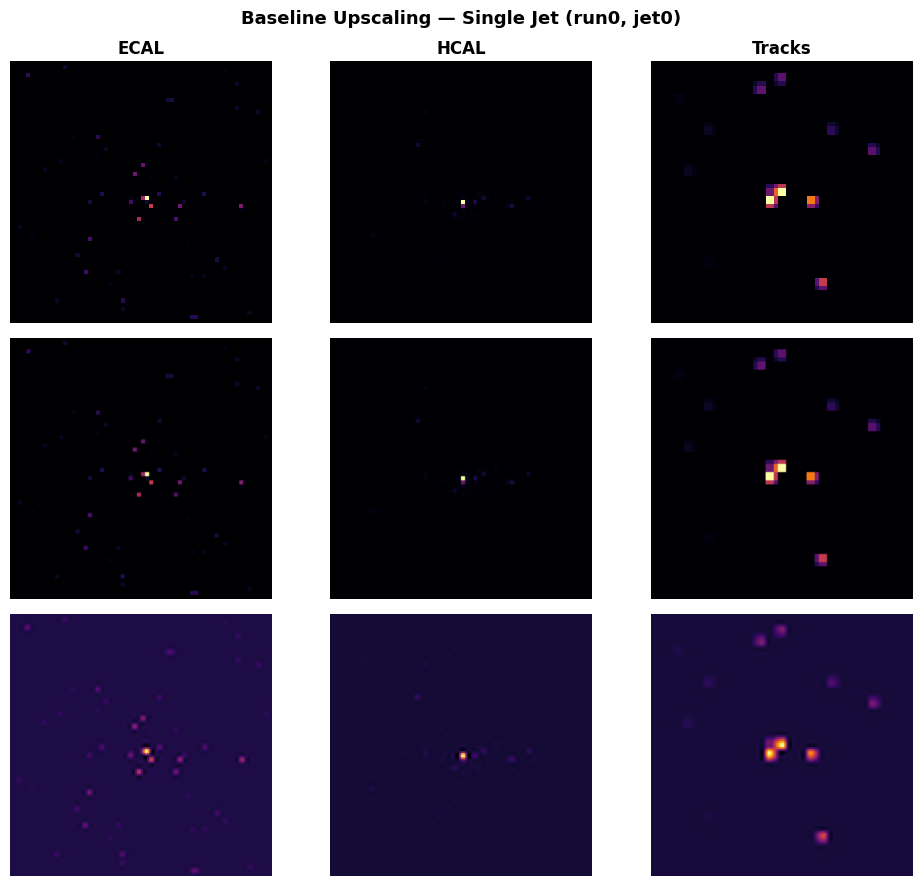

In [8]:
jet_lr = baselines[0]["lr"][0]       # (3, H, W)
jet_nn = baselines[0]["nearest"][0]
jet_bc = baselines[0]["bicubic"][0]

ch_labels = ['ECAL', 'HCAL', 'Tracks']
row_titles = ['LR', 'Nearest ×2', 'Bicubic ×2']

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
fig.suptitle('Baseline Upscaling — Single Jet (run0, jet0)', fontweight='bold', fontsize=13)

for r, (jet, rtitle) in enumerate(zip([jet_lr, jet_nn, jet_bc], row_titles)):
    for c in range(3):
        ax = axes[r, c]
        ax.imshow(jet[c], cmap='inferno', aspect='equal')
        ax.axis('off')
        if r == 0:
            ax.set_title(ch_labels[c], fontweight='bold')
        if c == 0:
            ax.set_ylabel(rtitle, fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
def total_energy(imgs):
    """imgs: (N, C, H, W) → (N,) total energy per jet."""
    return imgs.sum(axis=(1, 2, 3))

print("Energy preservation check (mean |E_LR - E_upsampled|):")
print("-" * 50)
for i, data in enumerate(baselines):
    e_lr = total_energy(data["lr"])
    e_nn = total_energy(data["nearest"])
    e_bc = total_energy(data["bicubic"])
    print(f"Run {i}")
    print(f"  |E_LR - E_NN| : {np.mean(np.abs(e_lr - e_nn)):.6f}")
    print(f"  |E_LR - E_BC| : {np.mean(np.abs(e_lr - e_bc)):.6f}")
    print()

Energy preservation check (mean |E_LR - E_upsampled|):
--------------------------------------------------
Run 0
  |E_LR - E_NN| : 180.236816
  |E_LR - E_BC| : 183.785599

Run 1
  |E_LR - E_NN| : 198.332642
  |E_LR - E_BC| : 202.319260

Run 2
  |E_LR - E_NN| : 200.326889
  |E_LR - E_BC| : 204.216507



In [10]:
def channel_fractions(imgs):
    """imgs: (N, C, H, W) → (N, C) fractional energy per channel."""
    ch_energy = imgs.sum(axis=(2, 3))                          # (N, C)
    total = ch_energy.sum(axis=1, keepdims=True)               # (N, 1)
    return ch_energy / np.where(total == 0, 1, total)          # avoid /0

print("Channel energy fractions (mean across jets):")
print("-" * 50)
for i, data in enumerate(baselines):
    frac_lr = channel_fractions(data["lr"]).mean(axis=0)
    frac_nn = channel_fractions(data["nearest"]).mean(axis=0)
    frac_bc = channel_fractions(data["bicubic"]).mean(axis=0)
    print(f"Run {i}")
    print(f"  LR      : {np.round(frac_lr, 4)}")
    print(f"  Nearest : {np.round(frac_nn, 4)}")
    print(f"  Bicubic : {np.round(frac_bc, 4)}")
    print()

Channel energy fractions (mean across jets):
--------------------------------------------------
Run 0
  LR      : [0.4879 0.312  0.2001]
  Nearest : [0.4879 0.312  0.2001]
  Bicubic : [0.4877 0.3121 0.2002]

Run 1
  LR      : [0.4644 0.3391 0.1966]
  Nearest : [0.4644 0.3391 0.1966]
  Bicubic : [0.4642 0.3391 0.1967]

Run 2
  LR      : [0.5015 0.3009 0.1976]
  Nearest : [0.5015 0.3009 0.1976]
  Bicubic : [0.5011 0.3012 0.1978]

